# Midterm project: Vehicle fuel efficiency

## Stage 1. Problem and scope

**Project question:** can the combined fuel consumption of a new passenger car be predicted from its basic characteristics (model year, engine size, number of cylinders, class, transmission type, fuel type)?

**Task type:** regression.
**Target (fixed):** `Combined (L/100 km)`: combined consumption, liters per 100 km.

**Metrics:**
- **MAE** (L/100 km): the main metric, easy to interpret;
- **RMSE** (L/100 km): penalizes large errors more heavily;
- **R²**: the share of explained variance.

**Success criterion:** the MAE of the best model on test is at least 50% lower than the MAE of the baseline (predicting the mean target value on train). The threshold can be refined after the first results.

**Context and scope:** Natural Resources Canada data for 2014-2025 (11829 rows). The data has no vehicle weight or power, so the models rely on engine size, number of cylinders, and vehicle class instead. We take this limitation into account in the error analysis. Plan: cleaning and EDA, feature engineering, a split protected against leakage (group split by the `Make` + `Model` pair), baseline, Linear Regression, Decision Tree, KNN, cross-validation, error analysis.

# Stage 2. Data loading and initial inspection

**Data source:** Natural Resources Canada, Fuel Consumption Ratings (Open Canada), official dataset page: https://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64

**License:** Open Government Licence - Canada.

**Where we load it from in the code:** a copy of this data in the GitHub repository `bgl96395/fuel-efficiency-dataset`, file `fuel_consumption_2014_2025.csv` (the `CSV_URL` link in the cell below). Size: 11829 rows, 15 columns, about 960 KB. We checked the years 2015-2024 against the official 2015-2024 file: the number of rows per year, the `Fuel type` distribution, the target statistics, and the number of missing values all match. We did not run a separate check against the official file for 2014 and 2025.

**What we use:** the whole file, model years **2014-2025** (11829 rows, 15 columns): the main dataset for training and testing. We do not mix in the 1995-2013 files: their ratings were recalculated using a different methodology.

**Known peculiarities:** no weight or power; `CO2 rating` and `Smog rating` are missing for the first years; several columns directly express the target (see 3.7).

**How we get the data:**
1. `pd.read_csv` reads the CSV directly from the `CSV_URL` link, no local files are needed, so the notebook runs the same way for all participants.
2. `df.columns.str.strip()` removes accidental spaces in column names.

In [1]:
import pandas as pd

CSV_URL = "https://raw.githubusercontent.com/bgl96395/fuel-efficiency-dataset/refs/heads/main/fuel_consumption_2014_2025.csv"
df = pd.read_csv(CSV_URL)
df.columns = df.columns.str.strip()

## Data size

`df.shape` shows the number of rows and columns.

In [2]:
print(df.shape)

(11829, 15)


**Result:** (11829, 15), i.e. 11829 cars and 15 columns.

**Conclusion:** this is enough for Linear Regression, Decision Tree, and KNN; the models train quickly.

## Data types and missing values

`df.info()` shows the type of each column and how many non-null values it has.

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11829 entries, 0 to 11828
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model year            11829 non-null  int64  
 1   Make                  11829 non-null  object 
 2   Model                 11829 non-null  object 
 3   Vehicle class         11829 non-null  object 
 4   Engine size (L)       11829 non-null  float64
 5   Cylinders             11829 non-null  int64  
 6   Transmission          11829 non-null  object 
 7   Fuel type             11829 non-null  object 
 8   City (L/100 km)       11829 non-null  float64
 9   Highway (L/100 km)    11829 non-null  float64
 10  Combined (L/100 km)   11829 non-null  float64
 11  Combined (mpg)        11829 non-null  int64  
 12  CO2 emissions (g/km)  11829 non-null  int64  
 13  CO2 rating            9633 non-null   float64
 14  Smog rating           8527 non-null   float64
dtypes: float64(6), int6

**Result:**
- Types: 6 float64 columns, 4 int64, 5 text (`object`).
- Missing values are present in only two columns: `CO2 rating` (9633 of 11829 filled) and `Smog rating` (8527 of 11829).

**Conclusion:** we are not using either column with missing values as features anyway because of data leakage (see below), so there is no need to fill the gaps.

## First rows

`df.head()` shows the first 5 rows to see what the data looks like.

In [4]:
print(df.head())

   Model year   Make       Model                 Vehicle class  \
0        2014  Acura         ILX                       Compact   
1        2014  Acura         ILX                       Compact   
2        2014  Acura  ILX Hybrid                       Compact   
3        2014  Acura     MDX 4WD  Sport utility vehicle: Small   
4        2014  Acura     RDX AWD  Sport utility vehicle: Small   

   Engine size (L)  Cylinders Transmission Fuel type  City (L/100 km)  \
0              2.0          4          AS5         Z              9.9   
1              2.4          4           M6         Z             11.2   
2              1.5          4          AV7         Z              6.0   
3              3.5          6          AS6         Z             12.7   
4              3.5          6          AS6         Z             12.1   

   Highway (L/100 km)  Combined (L/100 km)  Combined (mpg)  \
0                 6.7                  8.5              33   
1                 7.7                  9

**What we see:**
- The data starts in 2014, so the whole 2014-2025 file has been loaded.
- `Vehicle class` contains compound names (for example, `Compact` and `Sport utility vehicle: Small`). We will check the consistency of the notation in 3.3.
- `Transmission` consists of a type and a number of gears (`AS5`, `M6`, `AV7`): two features can be made from it.
- `Fuel type` is encoded with letters.
- Hybrids appear among the model names (for example, `ILX Hybrid`).

## List of columns

`df.columns.tolist()` prints the exact column names so that they can be referenced in code without typos.

**Candidate features:** `Model year`, `Make`, `Model`, `Vehicle class`, `Engine size (L)`, `Cylinders`, `Transmission`, `Fuel type`.

**Target:** `Combined (L/100 km)`.

**Excluded from features (data leakage):** `City (L/100 km)`, `Highway (L/100 km)`, `Combined (mpg)`, `CO2 emissions (g/km)`, `CO2 rating`, `Smog rating`. They directly express the target or are computed from it, and the model would get the answer instead of predicting it.

In [5]:
print(df.columns.tolist())

['Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)', 'Cylinders', 'Transmission', 'Fuel type', 'City (L/100 km)', 'Highway (L/100 km)', 'Combined (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


### Year range, fuel types, and statistics

The cell contains three checks:
1. Minimum and maximum year. **Result:** 2014 and 2025.
2. `value_counts()` for `Fuel type`. **Result:** X: 5574, Z: 5559, E: 423, D: 272, N: 1. The categories have very different frequencies, and `N` occurs only once (we will decide what to do with it during cleaning). Letter decoding per the NRCan documentation: X: regular gasoline, Z: premium gasoline, D: diesel, E: ethanol (E85), N: natural gas. Check against the Data Dictionary on the dataset page.
3. `describe()`: minimum, maximum, and mean for the numeric columns.

In [6]:
print(df["Model year"].min(), df["Model year"].max())
print(df["Fuel type"].value_counts())
df.describe()

2014 2025
Fuel type
X    5574
Z    5559
E     423
D     272
N       1
Name: count, dtype: int64


,Model year,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
count,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,9633.00000,8527.000000
mean,2019.109984,3.153496,5.621354,12.537417,9.183380,11.028439,27.371375,254.023586,4.61362,4.824675
std,3.355525,1.340000,1.865467,3.481807,2.246852,2.881756,7.381000,61.066271,1.55905,1.751139
min,2014.000000,0.900000,3.000000,4.000000,3.900000,4.000000,11.000000,94.000000,1.00000,1.000000
25%,2016.000000,2.000000,4.000000,10.100000,7.600000,9.000000,22.000000,209.000000,4.00000,3.000000
50%,2019.000000,3.000000,6.000000,12.200000,8.900000,10.700000,26.000000,250.000000,5.00000,5.000000
75%,2022.000000,3.700000,6.000000,14.600000,10.400000,12.700000,31.000000,292.000000,5.00000,6.000000
max,2025.000000,8.400000,16.000000,30.700000,20.900000,26.100000,71.000000,608.000000,10.00000,8.000000


**What we see in `describe()`:**
- Target `Combined (L/100 km)`: from 4.0 to 26.1, mean about 11.0, std about 2.9. The spread is sufficient, so there is something to predict.
- Engine size 0.9-8.4 L, cylinders 3-16: the values are plausible, no obvious errors.

**Dataset limitation (limitation):** the data has no vehicle weight or power.

**What we use instead of weight and power:** the project topic mentions weight and power, but they are not in the data. Engine size, number of cylinders, and vehicle class (`Vehicle class`) indirectly reflect the size and power of the car, so we use them. Auto MPG (UCI) can be considered as an additional dataset for the final.

# Stage 3. Data cleaning
We check: duplicates, missing values, ranges, categories, suspicious features (leakage).
We record every decision together with its reason.

## 3.1 Duplicates

**What we check:** whether the table contains completely identical rows (all 15 columns match).

**Why:** repeated rows would make the model learn from the same data several times and make the quality estimate less honest.

**How:** `df.duplicated().sum()` counts repeated copies of rows.

In [7]:
print("Duplicates:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(["Make", "Model", "Model year"]).head(10)

Duplicates: 0


,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating


**Result:** 0 duplicates found (`df.duplicated().sum()` = 0). The second part of the cell returned an empty table because there are no row copies.

**Decision:** we do not remove anything.

**Reason:** there are no completely identical rows, so the model will not see the same data several times, and the quality estimate will not be distorted by repeats.

## 3.2 Missing values in CO2 rating and Smog rating

**What we do:** for each year, we count how many ratings are missing.

**Why:** we are testing the hypothesis that the missing values are tied to the year (the rating was not published) rather than scattered randomly.
This is needed to understand the cause of the missing values, even though we do not fill them.

In [8]:
by_year = df.groupby("Model year").agg(
    rows=("Model year", "size"),
    co2_rating_missing=("CO2 rating", lambda s: s.isna().sum()),
    smog_rating_missing=("Smog rating", lambda s: s.isna().sum()),
)
print(by_year)

            rows  co2_rating_missing  smog_rating_missing
Model year                                               
2014        1068                1068                 1068
2015        1128                1128                 1128
2016        1106                   0                 1106
2017        1058                   0                    0
2018        1083                   0                    0
2019        1056                   0                    0
2020         975                   0                    0
2021         970                   0                    0
2022         976                   0                    0
2023         919                   0                    0
2024         789                   0                    0
2025         701                   0                    0


**Result:** the missing values in the ratings are tied to the year rather than scattered randomly:
- `CO2 rating` is missing in all rows of 2014 and 2015 (1068 + 1128 = 2196); from 2016 on there are no missing values;
- `Smog rating` is missing in all rows of 2014, 2015, and 2016 (1068 + 1128 + 1106 = 3302); from 2017 on there are no missing values.

The hypothesis is confirmed: there are no values in the file for these years.

**Decision:** we do not fill the missing values and do not remove the rows that contain them.

**Reason:** the `CO2 rating` and `Smog rating` columns will be dropped from the features as leakage (they almost directly express the target), so there is no point in filling them. At the same time, the rows for 2014-2016 are kept: we remove only the columns, not the cars, and do not lose 3302 observations.

## 3.3 Categorical columns

**What we do:** we look at which values occur in `Vehicle class`, `Transmission`, and `Fuel type`, and check the text columns for extra spaces and inconsistent letter case.

**Why:** models work with numbers, so the text categories will have to be encoded later. If the same category is written in different ways (for example `Compact` and `compact `), the encoder will treat them as different, and the feature will become less informative.

**How:** `value_counts()` shows all values and their frequency. The check for spaces and letter case compares the number of unique values before and after normalization.

In [9]:
df["Transmission"].value_counts()

Transmission
AS8     2285
AS6     1494
M6      1210
A8       945
A6       857
AM7      787
A9       699
AS10     569
AV       507
AS7      341
A10      324
AM8      296
M5       208
AS9      187
AM6      177
AV6      164
AV7      156
M7       152
AV8      144
A5        84
A4        65
A7        58
AV10      46
AS5       34
AV1       28
AM9        6
AM5        4
AS4        2
Name: count, dtype: int64

In [10]:
print(df["Vehicle class"].value_counts())

Vehicle class
Sport utility vehicle: Small       2203
Mid-size                           1639
Sport utility vehicle: Standard    1482
Compact                            1360
Pickup truck: Standard             1015
Subcompact                          964
Full-size                           894
Two-seater                          753
Minicompact                         535
Station wagon: Small                333
Pickup truck: Small                 240
Minivan                             117
Special purpose vehicle             110
Station wagon: Mid-size              92
Van: Passenger                       70
Van: Cargo                           22
Name: count, dtype: int64


In [12]:
for col in ["Make", "Model", "Vehicle class", "Transmission", "Fuel type"]:
    n_space = (df[col] != df[col].str.strip()).sum()
    n_unique = df[col].nunique()
    n_unique_norm = df[col].str.strip().str.lower().nunique()
    print(col, "| with extra spaces:", n_space,
          "| unique:", n_unique, "| after normalization:", n_unique_norm)

Make | with extra spaces: 0 | unique: 44 | after normalization: 44
Model | with extra spaces: 22 | unique: 2294 | after normalization: 2268
Vehicle class | with extra spaces: 0 | unique: 16 | after normalization: 16
Transmission | with extra spaces: 0 | unique: 28 | after normalization: 28
Fuel type | with extra spaces: 0 | unique: 5 | after normalization: 5


**Result:**
- `Make`: 44 values, `Vehicle class`: 16, `Transmission`: 28, `Fuel type`: 5. There are no spaces or inconsistent letter case in these columns; the values before and after normalization match.
- `Model`: 22 rows have extra spaces at the edges, and of 2294 unique names 2268 remain after normalization. Analysis in 3.5.
- Rare values exist in `Transmission` (`AS4`: 2, `AM5`: 4, `AM9`: 6) and in `Vehicle class` (`Van: Cargo`: 22), as well as among the makes (for example, `SRT`: 2 rows).

**Decision:** we do not change `Make`, `Vehicle class`, `Transmission`, and we do not merge or remove rare categories.

**Reason:** these are not recording errors but real models. We will later split the transmission into a type and a number of gears, which will remove the problem of rare codes. We will configure the encoder to handle unknown categories, because rare values may appear only in test.

## 3.4 Fuel type = N

**What we do:** we look at the only row with fuel type `N`.

**Why:** one row out of 11829 will not teach the model anything. When splitting into train and test, it can end up in only one part, and then the encoder will encounter an unknown category. We need to decide what to do with it.

In [13]:
print(df[df["Fuel type"] == "N"])

print("Before:", df.shape)
df = df[df["Fuel type"] != "N"].reset_index(drop=True)
print("After:", df.shape)
print(df["Fuel type"].value_counts())

      Model year       Make             Model Vehicle class  Engine size (L)  \
2432        2016  Chevrolet  Impala Dual Fuel      Mid-size              3.6   

      Cylinders Transmission Fuel type  City (L/100 km)  Highway (L/100 km)  \
2432          6          AS6         N             15.2                 9.5   

      Combined (L/100 km)  Combined (mpg)  CO2 emissions (g/km)  CO2 rating  \
2432                 12.7              22                   213         6.0   

      Smog rating  
2432          NaN  
Before: (11829, 15)
After: (11828, 15)
Fuel type
X    5574
Z    5559
E     423
D     272
Name: count, dtype: int64


**Result:** the only row with `N` is a Chevrolet Impala Dual Fuel 2016 (3.6 L, 6 cylinders, AS6). After removal the table has 11828 rows and 4 fuel types: X (5574), Z (5559), E (423), D (272).

**Decision:** we remove this row.

**Reason:** one row will not let the model learn a pattern. `N` cannot be merged with another category, because it is a different kind of fuel. The loss is about 0.01% of the data.

## 3.5 Model names (Model)

**What we do:** we look for extra spaces and inconsistent letter case in identical names in `Model`.

**Why:** we plan to use the `Make` + `Model` pair for the group split. If one model is written in different ways, it will end up in different groups, and almost identical cars will land in both train and test (leakage).


In [14]:
bad = df[df["Model"] != df["Model"].str.strip()]
print("Rows with spaces:", len(bad))
bad["Model"].map(repr).head(10)

Rows with spaces: 22


2779               'XF AWD '
5078                 'CX-5 '
6529           'A6 quattro '
6530           'A6 quattro '
6531           'A6 allroad '
6533                  'A8L '
6534                  'A8L '
7183         'A 220 4MATIC '
7195    'AMG CLA 35 4MATIC '
7196    'AMG CLA 45 4MATIC '
Name: Model, dtype: object

In [15]:
s = df["Model"].str.strip()
print("after strip:", s.nunique(), "| after strip + lower:", s.str.lower().nunique())

after strip: 2283 | after strip + lower: 2268


In [16]:
low = s.str.lower()
n_variants = s.groupby(low).nunique()
for key in n_variants[n_variants > 1].index:
    print(sorted(s[low == key].unique()))

['ALPINA B8 Gran Coupe', 'Alpina B8 Gran Coupe']
['ALPINA XB7', 'Alpina XB7']
['F-PACE P250', 'F-Pace P250']
['F-PACE P400', 'F-Pace P400']
['F-PACE P550 SVR', 'F-Pace P550 SVR']
['GranTurismo', 'Granturismo']
['GranTurismo Convertible', 'Granturismo Convertible']
['Huracan EVO Coupe', 'Huracan evo Coupe']
['Huracan EVO Coupe AWD', 'Huracan evo Coupe AWD']
['Huracan EVO Spyder', 'Huracan evo Spyder']
['Huracan EVO Spyder AWD', 'Huracan evo Spyder AWD']
['LaCrosse', 'Lacrosse']
['LaCrosse AWD', 'Lacrosse AWD']
['LaCrosse eAssist', 'Lacrosse eAssist']
['Tacoma 4WD D-Cab TRD Off-Road/PRO', 'Tacoma 4WD D-Cab TRD Off-Road/Pro']


In [17]:
pairs_before = df[["Make", "Model"]].drop_duplicates().shape[0]

df["Model"] = df["Model"].str.lower()

pairs_after = df[["Make", "Model"]].drop_duplicates().shape[0]
print("Make+Model pairs: before", pairs_before, "| after", pairs_after,
      "| removed", pairs_before - pairs_after)
print("Unique Model:", df["Model"].nunique())

Make+Model pairs: before 2295 | after 2280 | removed 15
Unique Model: 2279


**Result:**
- In `Model`, 22 rows have extra spaces at the edges. After `strip`, the number of unique names fell from 2294 to 2283, and after `strip` + `lower` there are 2268.
- 15 names are written with different letter case for the same model (for example `LaCrosse` and `Lacrosse`, `F-PACE P250` and `F-Pace P250`, `Huracan EVO Coupe` and `Huracan evo Coupe`).
- In the cell above only `lower()` was applied to `Model`: the number of `Make` + `Model` pairs became 2280 instead of 2295 (15 removed), and there are 2279 unique names. Names that differ only by a trailing space (11 names, 22 rows) remain different for now. With `strip` + `lower` there would be 2268 names and 2269 pairs.
- There is one more pair than names: the same name occurs for two different makes.

**Decision:** we converted `Model` to lower case. The edge spaces in 22 rows of `df` have not been removed yet.

**Reason:** these are the same cars written in different ways. In the group split they would end up in different groups, and almost identical cars would be in both train and test at the same time (leakage). We need to group by the `Make` + `Model` pair, not by `Model` alone: otherwise two different cars with the same name from different makes would be merged. We do not use `Model` itself as a feature, there are too many names.

## 3.6 Ranges and outliers
**What we do:** we look at the minimum and maximum of the key numeric columns.

**Why:** to find physically impossible values (a zero engine, negative consumption). Large and small but real values must not be removed.

In [18]:
df[["Engine size (L)", "Cylinders", "Combined (L/100 km)"]].describe()

,Engine size (L),Cylinders,Combined (L/100 km)
count,11828.000000,11828.000000,11828.000000
mean,3.153458,5.621322,11.028297
std,1.340050,1.865542,2.881837
min,0.900000,3.000000,4.000000
25%,2.000000,4.000000,9.000000
50%,3.000000,6.000000,10.700000
75%,3.700000,6.000000,12.700000
max,8.400000,16.000000,26.100000


**Result:** for all 11828 rows: `Engine size` 0.9-8.4 L, `Cylinders` 3-16, `Combined (L/100 km)` 4.0-26.1 (mean about 11, std about 2.9). There are no zeros or negative values.

**Decision:** we do not remove outliers.

**Reason:** high consumption for powerful cars and low consumption for hybrids are real cars, not errors. Only physically impossible values should be removed, and there are none.

## 3.7 Leakage columns
**What we do:** we fix the list of columns that must not be used as features.

**Why:** most of these columns almost directly express the target `Combined (L/100 km)`: `City` and `Highway` are its components, `Combined (mpg)` is the same consumption in other units, `CO2 emissions` is calculated from consumption using a coefficient for the fuel type, and `CO2 rating` is derived from CO2. The model would get the answer as a hint and show nice but false results. `Smog rating` is not directly related to consumption, but we remove it as well: it is an official rating rather than a characteristic of the car, and it is missing for 2014-2016.

**How:** we save the list in `leak_cols`. We do not remove them from `df` yet, because they are needed for EDA (the correlation matrix will show the problem). We will remove them when assembling the features.

In [19]:
leak_cols = [
    "City (L/100 km)", "Highway (L/100 km)", "Combined (mpg)",
    "CO2 emissions (g/km)", "CO2 rating", "Smog rating",
]
print(leak_cols)

['City (L/100 km)', 'Highway (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


**Result:** 6 columns are fixed in `leak_cols`: `City (L/100 km)`, `Highway (L/100 km)`, `Combined (mpg)`, `CO2 emissions (g/km)`, `CO2 rating`, `Smog rating`.

**Decision:** these columns will not become features. They remain in `df` for now.

**Reason:** five of the six columns express the target directly or through a conversion, and the sixth (`Smog rating`) is removed according to a project rule and because of missing values. We keep them until the EDA to show on the correlation matrix why they would cause leakage. We will remove them from the feature table when assembling the features (stage 5), before the split and before any `fit`.

## Stage 3 summary
- **Rows:** was 11829, now 11828 (1 row with `Fuel type = N` removed).
- **Duplicates:** none.
- **Missing values:** only `CO2 rating` (2014-2015) and `Smog rating` (2014-2016). We do not fill them, both columns are in `leak_cols`.
- **Categories:** we do not change `Vehicle class`, `Transmission`, `Make`; rare values are visible in `value_counts` (3.3). In `Model` we normalized the letter case (15 spelling variants). Edge spaces (22 rows) have not been removed yet.
- **Outliers:** we looked at the minimum and maximum, did not remove anything, there are no impossible values.
- **Leakage:** 6 columns that will not become features are fixed in `leak_cols`.
- **Notes for the next stages:** split `Transmission` into a type and a number of gears (507 rows have `AV` without a number); use the `Make` + `Model` pair for the group split; configure the encoder for unknown categories because of rare values in `Vehicle class`, `Transmission`, and `Make`.

# Stage 4. EDA

We build 5 plots, each with a short conclusion. Target: `Combined (L/100 km)`.
Data after cleaning: 11828 rows, model years 2014-2025.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
TARGET = "Combined (L/100 km)"
print(df.shape)

(11828, 15)


### 4.1 Target distribution

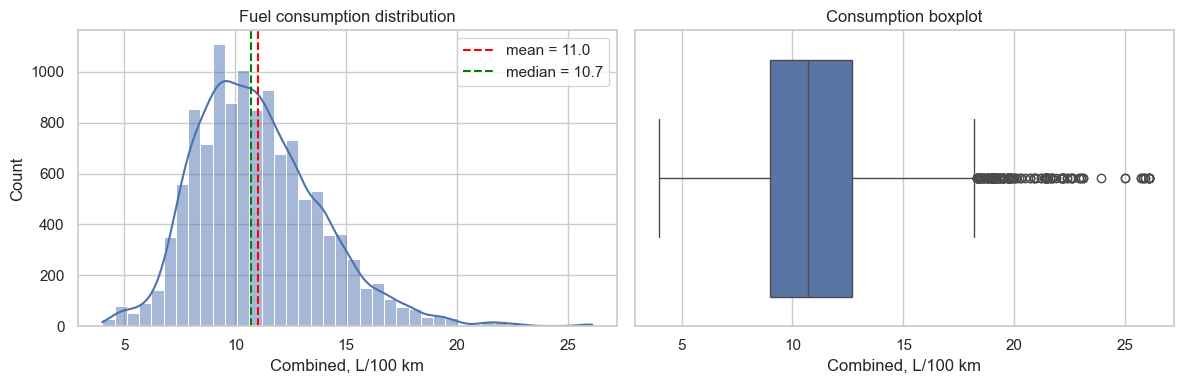

count    11828.00
mean        11.03
std          2.88
min          4.00
25%          9.00
50%         10.70
75%         12.70
max         26.10
Name: Combined (L/100 km), dtype: float64
Skewness (skew): 0.81


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0])
axes[0].axvline(df[TARGET].mean(), color="red", linestyle="--", label=f"mean = {df[TARGET].mean():.1f}")
axes[0].axvline(df[TARGET].median(), color="green", linestyle="--", label=f"median = {df[TARGET].median():.1f}")
axes[0].set_title("Fuel consumption distribution")
axes[0].set_xlabel("Combined, L/100 km")
axes[0].legend()

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Consumption boxplot")
axes[1].set_xlabel("Combined, L/100 km")

plt.tight_layout()
plt.show()

print(df[TARGET].describe().round(2))
print("Skewness (skew):", round(df[TARGET].skew(), 2))

**Conclusion:**
- The distribution is right-skewed (skew 0.81): most cars consume 9-12.7 L/100 km (25% and 75% quantiles), and the right tail extends to 26.1.
- The mean of 11.03 is greater than the median of 10.7 because of the tail. Std 2.88.
- The points on the right of the boxplot are real powerful cars (V8, V12, vans), not errors, so we do not remove them.
- For the models: the "predict the mean" baseline will give an error on the order of std (about 2.9). The tail means that the models will make the largest errors on rare heavy cars.

### 4.2 Engine size and consumption

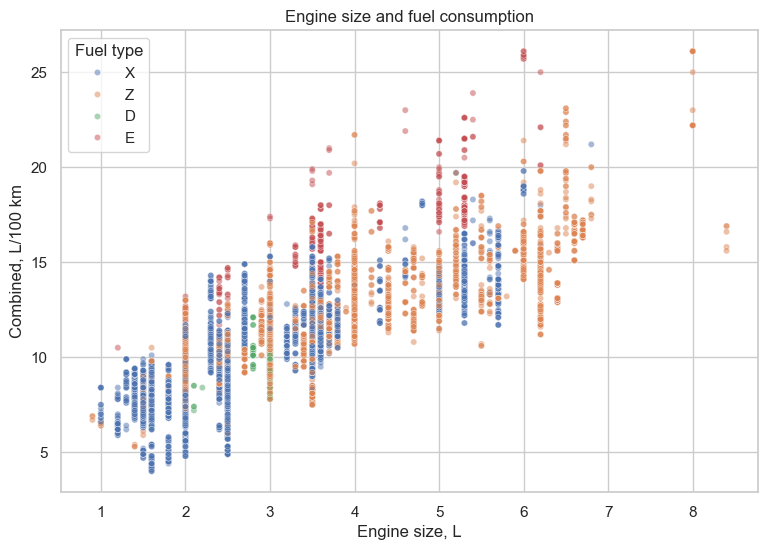

Correlation between Engine size and target: 0.811


In [22]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="Engine size (L)", y=TARGET,
    hue="Fuel type", hue_order=["X", "Z", "D", "E"],
    alpha=0.5, s=20
)
plt.title("Engine size and fuel consumption")
plt.xlabel("Engine size, L")
plt.ylabel("Combined, L/100 km")
plt.show()

print("Correlation between Engine size and target:", round(df["Engine size (L)"].corr(df[TARGET]), 3))

**Conclusion:**
- The relationship is strong and positive, correlation 0.81: the bigger the engine, the higher the consumption.
- For the same size the spread is large (hybrids at the bottom, heavy SUVs at the top), so engine size alone is not enough, and vehicle class and fuel type are needed.
- `E` points (ethanol E85) lie higher than the others at the same size: this is a fuel effect, not an engine effect.
- For the models: Linear Regression will capture the overall trend, while Decision Tree and KNN will better handle nonlinearity and the influence of `Fuel type`.

### 4.3 Correlation matrix

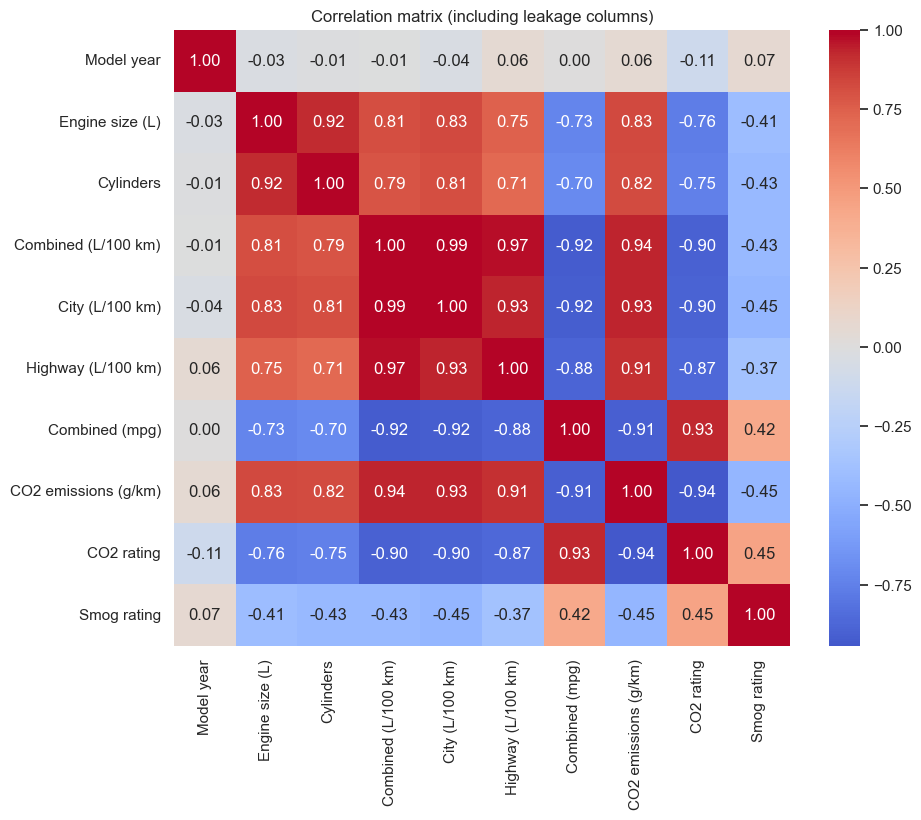

City (L/100 km)         0.992
Highway (L/100 km)      0.971
CO2 emissions (g/km)    0.939
Combined (mpg)         -0.922
CO2 rating             -0.902
Engine size (L)         0.811
Cylinders               0.789
Smog rating            -0.431
Model year             -0.006
Name: Combined (L/100 km), dtype: float64


In [23]:
num_cols = [
    "Model year", "Engine size (L)", "Cylinders", TARGET,
    "City (L/100 km)", "Highway (L/100 km)", "Combined (mpg)",
    "CO2 emissions (g/km)", "CO2 rating", "Smog rating",
]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix (including leakage columns)")
plt.show()

print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3))

**Conclusion:**
- The columns from `leak_cols` are almost perfectly related to the target: `City` 0.99, `Highway` 0.97, `CO2 emissions` 0.94, `Combined (mpg)` -0.92, `CO2 rating` -0.90. They express the target directly, so we exclude them from the features. `Smog rating` is related more weakly (-0.43), and we exclude it too (project rule, missing values).
- Among the allowed features the strongest are: `Engine size` (0.81) and `Cylinders` (0.79).
- `Model year` is almost unrelated to the target (-0.01).
- `Engine size` and `Cylinders` are strongly correlated with each other (multicollinearity): this is not a problem for trees and KNN, but for Linear Regression we take it into account when interpreting coefficients.

### 4.4 Cylinders and fuel type

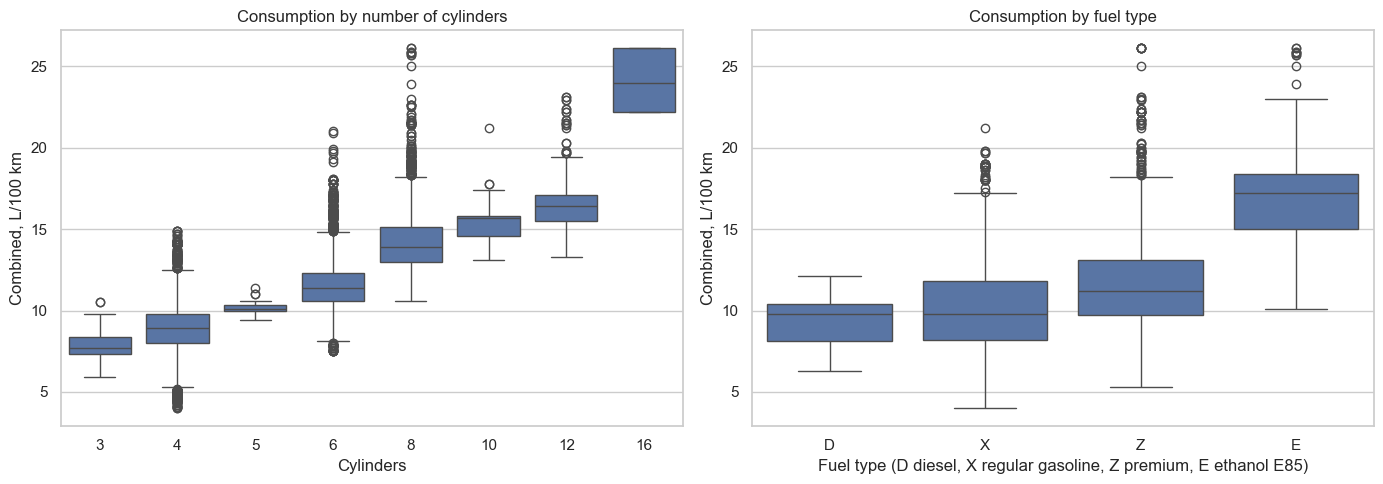

           count   mean
Cylinders              
3            197   7.74
4           5156   8.91
5             28  10.19
6           3835  11.58
8           2283  14.35
10            72  15.42
12           243  16.60
16            14  24.13
           count   mean
Fuel type              
D            272   9.31
E            423  16.97
X           5574  10.08
Z           5559  11.61


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Cylinders", y=TARGET, ax=axes[0])
axes[0].set_title("Consumption by number of cylinders")
axes[0].set_xlabel("Cylinders")
axes[0].set_ylabel("Combined, L/100 km")

sns.boxplot(data=df, x="Fuel type", y=TARGET, order=["D", "X", "Z", "E"], ax=axes[1])
axes[1].set_title("Consumption by fuel type")
axes[1].set_xlabel("Fuel type (D diesel, X regular gasoline, Z premium, E ethanol E85)")
axes[1].set_ylabel("Combined, L/100 km")

plt.tight_layout()
plt.show()

print(df.groupby("Cylinders")[TARGET].agg(["count", "mean"]).round(2))
print(df.groupby("Fuel type")[TARGET].agg(["count", "mean"]).round(2))

**Conclusion:**
- Consumption grows with the number of cylinders: on average 3 cyl. 7.7, 4 cyl. 8.9, 6 cyl. 11.6, 8 cyl. 14.4, 12 cyl. 16.6 L/100 km.
- The groups are of very different sizes: 4 cyl. 5156 cars, 6 cyl. 3835, 8 cyl. 2283, while 5 cyl. only 28, 10 cyl. 72, 16 cyl. 14. Estimates in the rare groups are less reliable, and we expect larger errors there.
- Fuel type shifts consumption strongly: E 17.0, Z 11.6, X 10.1, D 9.3.
- The spread remains within groups, so class and transmission are also needed.
- For the models: we encode `Fuel type` with one-hot, and `Cylinders` can be kept numeric.

### 4.5 Years and vehicle class

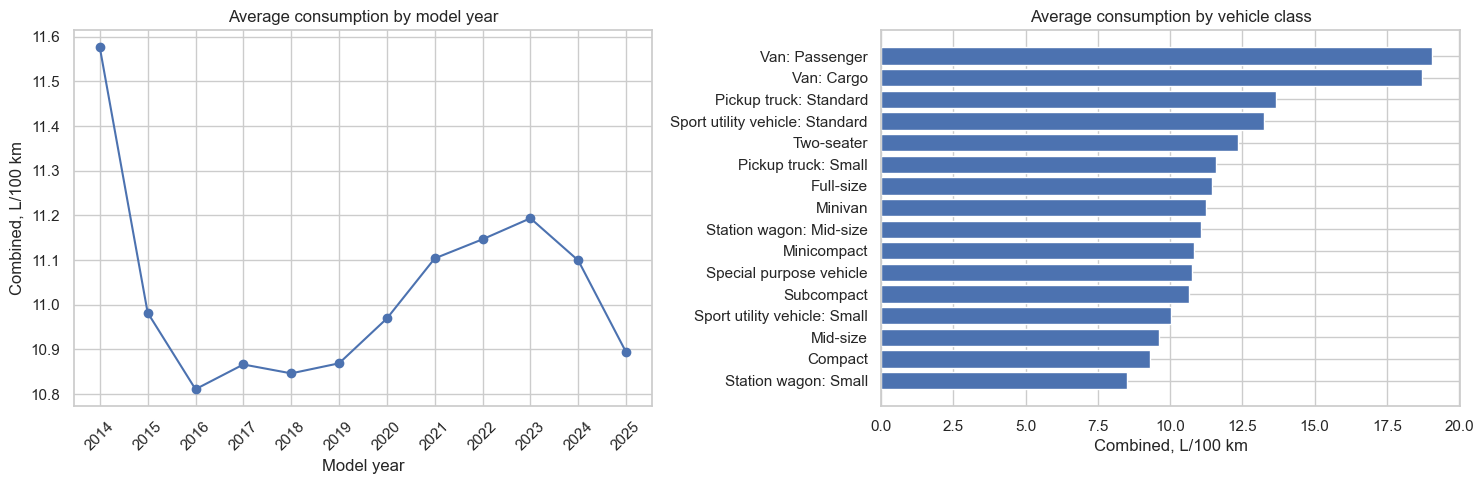

Model year
2014    11.58
2015    10.98
2016    10.81
2017    10.87
2018    10.85
2019    10.87
2020    10.97
2021    11.10
2022    11.15
2023    11.19
2024    11.10
2025    10.89
Name: Combined (L/100 km), dtype: float64
Vehicle class
Station wagon: Small                8.51
Compact                             9.29
Mid-size                            9.62
Sport utility vehicle: Small       10.02
Subcompact                         10.65
Special purpose vehicle            10.75
Minicompact                        10.82
Station wagon: Mid-size            11.06
Minivan                            11.23
Full-size                          11.45
Pickup truck: Small                11.60
Two-seater                         12.36
Sport utility vehicle: Standard    13.25
Pickup truck: Standard             13.65
Van: Cargo                         18.72
Van: Passenger                     19.08
Name: Combined (L/100 km), dtype: float64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

yearly = df.groupby("Model year")[TARGET].mean()
axes[0].plot(yearly.index, yearly.values, marker="o")
axes[0].set_title("Average consumption by model year")
axes[0].set_xlabel("Model year")
axes[0].set_ylabel("Combined, L/100 km")
axes[0].set_xticks(yearly.index)
axes[0].tick_params(axis="x", rotation=45)

by_class = df.groupby("Vehicle class")[TARGET].mean().sort_values()
axes[1].barh(by_class.index, by_class.values)
axes[1].set_title("Average consumption by vehicle class")
axes[1].set_xlabel("Combined, L/100 km")

plt.tight_layout()
plt.show()

print(yearly.round(2))
print(by_class.round(2))

**Conclusion:**
- By year: 2014 stands out (11.58); from 2015 to 2025 consumption barely changes (10.8-11.2). The improvement in engine efficiency is offset by the growing share of heavy SUVs and pickups, so the correlation with year is about zero.
- Class has a strong influence: the most economical are `Station wagon: Small` (8.5), `Compact` (9.3), `Mid-size` (9.6); the most expensive to run are `SUV: Standard` (13.3), `Pickup truck: Standard` (13.7), `Van: Cargo` (18.7), `Van: Passenger` (19.1).
- Vans are rare (22 and 70 cars), so large errors are possible there.
- For the models: `Vehicle class` is an important feature, and we encode it with one-hot. We will decide on the value of `Model year` during feature selection. For the group split we remember that one model repeats across different years.

## Stage 4 summary

- **Target:** right-skewed (mean 11.03, median 10.7, std 2.88),
  heavy tail up to 26.1.
- **Strong features:** `Engine size` (0.81), `Cylinders` (0.79),
  `Fuel type`, `Vehicle class`.
- **Weak feature:** `Model year` (-0.01).
- **Leakage confirmed:** 5 columns from `leak_cols` correlate with
  the target at 0.90-0.99, we exclude them when assembling the features.
- **Multicollinearity:** `Engine size` and `Cylinders`.
- **Rare groups:** 5, 10, and 16 cylinders; `Van: Cargo`,
  `Van: Passenger`.
- **For stage 5:** one-hot for `Fuel type` and `Vehicle class`, splitting
  `Transmission` into a type and a number of gears, new features (transmission
  type, number of gears, displacement per cylinder). 

## Stage 5. Feature engineering

We prepare the features: we split `Transmission`, add a new feature,
set up encoding and missing values, and fix the final set.

Parsing the transmission code and dividing two columns are computed row by
row and immediately. The median and one-hot are only described: they learn from
the data, so `fit` will happen inside the pipeline on train. All models work on
the original units. Therefore there is essentially one preprocessor
(`preprocessor_base`), and `preprocessor_knn` is its alias for KNN.


## 5.1 New features

**What we do:** from `Transmission` we take the type (`trans_type`) and the number of gears (`gears`), and add `disp_per_cyl` (engine size / number of cylinders).

**Why:**
- `Transmission` has 28 codes, some of them rare (`AS4`: 2 rows, `AM5`: 4). After parsing, 5 types and one number remain.
- The data has no weight or power, so `disp_per_cyl` partially replaces them: engines with the same number of cylinders but different displacement get different values.

In [26]:
tr = df["Transmission"].str.extract(r"^([A-Z]+)(\d*)$")
df["trans_type"] = tr[0]
df["gears"] = pd.to_numeric(tr[1], errors="coerce")

df["disp_per_cyl"] = df["Engine size (L)"] / df["Cylinders"]

print(df["trans_type"].value_counts())
print("Missing values in gears:", df["gears"].isna().sum())
print(df.groupby("trans_type")[TARGET].mean().round(2))
print(df[["disp_per_cyl", "gears"]].corrwith(df[TARGET]).round(3))

trans_type
AS    4911
A     3032
M     1570
AM    1270
AV    1045
Name: count, dtype: int64
Missing values in gears: 507
trans_type
A     12.44
AM    10.93
AS    11.20
AV     7.71
M     10.06
Name: Combined (L/100 km), dtype: float64
disp_per_cyl    0.524
gears           0.165
dtype: float64


**Result:**
- Transmission types: `AS` 4911, `A` 3032, `M` 1570, `AM` 1270, `AV` 1045.
- Missing values in `gears` only for `AV` (CVT), 507 rows: a CVT has no fixed gears, this is not a data error.
- Average consumption: `AV` 7.7, `M` 10.1, `AM` 10.9, `AS` 11.2, `A` 12.4 L/100 km.
- Correlation with the target: `disp_per_cyl` 0.52, `gears` 0.17.

**Conclusion:** `trans_type` clearly distinguishes consumption, and `disp_per_cyl` has a noticeable relationship with the target (0.52). `gears` is related more weakly, but it describes the transmission differently than the type does.

**Decision:** we keep all three features. We do not fill the missing values in `gears` here.
**Reason:** the median is computed from the data, so it must be filled only on train, inside the pipeline. The fact that it is a CVT is not lost: it is stored in `trans_type`.

## 5.2 Encoding and missing values

**What we do:** we describe the preprocessor without `fit`: filling missing values
and one-hot encoding. 

**Why:**

- Linear Regression, Decision Tree, and KNN work on the
  original units.
- Encoding is needed for all categorical columns `Vehicle class`,
  `Fuel type`, `trans_type`: they have no order, so one-hot rather than
  the numbers 1, 2, 3.
- We fill the missing values in `gears` (507, CVT) with the median, because
  models do not work with missing values.
- `handle_unknown="ignore"` is needed because of rare categories (3.3): if a
  category appears only in test, the encoder will not fail.

**Limitation for KNN:** without scaling, distances are determined by
features with a large numeric range (`Cylinders` 3-16, `gears`,
`Model year` 2014-2025), while one-hot columns (0/1) barely have any influence. We
check this in 7.6 (KNN with and without `Model year`).

In [29]:
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_cols = ["Model year", "Engine size (L)", "Cylinders", "disp_per_cyl", "gears"]
cat_cols = ["Vehicle class", "Fuel type", "trans_type"]

preprocessor_base = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

preprocessor_knn = preprocessor_base

**Result:** the preprocessor is created, and it has not seen the data yet.

**Decision:** `preprocessor_knn`
is identical to `preprocessor_base`, and the separate name remains only for
code readability at stage 7.

**Reason:** a project requirement. Everything that learns from the data (the median,
the list of categories) is trained on train inside the pipeline.

## 5.3 Feature selection

**What we do:** we assemble `X` and `y` and check that there are no columns from `leak_cols` in `X`.

**Why:** in 3.7 we promised to remove them when assembling the features. `assert` will stop the notebook if a leak gets in there.

In [30]:
X = df[num_cols + cat_cols]
y = df[TARGET]

assert not set(leak_cols) & set(X.columns)
assert TARGET not in X.columns
print("X:", X.shape, "| y:", y.shape)
print("Categories: Vehicle class", X["Vehicle class"].nunique(),
      "| Fuel type", X["Fuel type"].nunique(),
      "| trans_type", X["trans_type"].nunique())
print("Missing values:", X.isna().sum()[X.isna().sum() > 0].to_dict())

X: (11828, 8) | y: (11828,)
Categories: Vehicle class 16 | Fuel type 4 | trans_type 5
Missing values: {'gears': 507}


**Result:**
- `X`: (11828, 8), `y`: (11828,). The sizes match.
- Categories: `Vehicle class` 16, `Fuel type` 4, `trans_type` 5. After one-hot there are 25 columns, which is not many.
- Missing values only in `gears` (507, CVTs), we will fill them in the pipeline.
- Columns from `leak_cols` and the target are absent from `X` (verified with `assert`).

**Decision:** 8 features: 5 numeric and 3 categorical.

**Reason:** we take the characteristics of the car that describe the engine, transmission, fuel, and size. We do not take `Make` (44 values) and `Model` (2269 names): one-hot would inflate the number of columns and blur the distances in KNN. We keep `Model year` conditionally (its relationship with the target is about zero) and will check it at stage 7 by comparing MAE with and without the year.

# Stage 6. Split and leakage protection

We split the data into train, validation, and test. We touch test once, at the very end.

## 6.1 Why a group split

In the data, the same model appears in different years (on average 5 rows per `Make` + `Model` pair), and its characteristics barely change. With an ordinary random split, such a car would end up in both train and test, and the model would get an almost ready answer. Therefore we split by groups: all rows of one `Make` + `Model` pair go entirely into one part.

**About stratify:** stratification is needed for classification, and ours is regression, so we do not use it. Instead we will check that the target distribution in the parts is similar.

**Proportions:** train 70%, validation 15%, test 15%. Validation is needed for choosing the model and features (for example, whether `Model year` is needed), and test only for the final evaluation.

### 1. Split

In [32]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
groups = df["Make"] + " | " + df["Model"].str.strip()

split1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
temp_idx, test_idx = next(split1.split(X, y, groups))
X_temp, y_temp, g_temp = X.iloc[temp_idx], y.iloc[temp_idx], groups.iloc[temp_idx]
X_test, y_test, g_test = X.iloc[test_idx], y.iloc[test_idx], groups.iloc[test_idx]

split2 = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=RANDOM_STATE)
train_idx, val_idx = next(split2.split(X_temp, y_temp, g_temp))
X_train, y_train, g_train = X_temp.iloc[train_idx], y_temp.iloc[train_idx], g_temp.iloc[train_idx]
X_val, y_val, g_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx], g_temp.iloc[val_idx]

print("train:", len(X_train), "| val:", len(X_val), "| test:", len(X_test))

train: 8268 | val: 1809 | test: 1751


### 2. Leakage check

In [33]:
print("train and val:", len(set(g_train) & set(g_val)))
print("train and test:", len(set(g_train) & set(g_test)))
print("val and test:", len(set(g_val) & set(g_test)))

print("Mean target: train", round(y_train.mean(), 2),
      "| val", round(y_val.mean(), 2),
      "| test", round(y_test.mean(), 2))

train and val: 0
train and test: 0
val and test: 0
Mean target: train 11.03 | val 10.98 | test 11.07


### 3. Comparison with an ordinary split

In [35]:
from sklearn.model_selection import train_test_split

g_a, g_b = train_test_split(groups, test_size=0.15, random_state=42)

print("Regular split:", round(g_b.isin(g_a).mean() * 100, 1), "%")
print("Group split:", round(g_test.isin(g_train).mean() * 100, 1), "%")

Regular split: 94.7 %
Group split: 0.0 %


**Result:**
- Train 8268 rows (69.9%, 1587 groups), validation 1809 (15.3%, 341 groups), test 1751 (14.8%, 341 groups).
- There are no group overlaps between the parts (0, 0, 0).
- The target in the parts is similar: mean 11.03 (train), 10.98 (val), 11.07 (test), std 2.94, 2.66, 2.83.
- With a random split, 94.7% of test rows would have a "twin" in train, while with the group split 0%. This shows that an ordinary split would have given inflated quality.
- All categories of `Vehicle class`, `Fuel type`, `trans_type` from val and test are present in train. Insignificant: `Van: Passenger` is absent from validation.

**How we avoid leakage:**

1. Groups by `Make` + `Model`: one model is never in
   both train and test at the same time.
2. 6 columns that express the target have been removed from the features (stages 3.7, 5.3).
3. The split is done before any `fit`: the median and one-hot will be learned
   only on train inside the pipeline.
4. We use validation for choosing the model and features, and test only
   for the final evaluation.
5. We do cross-validation only on train and also by groups
   (`GroupKFold`).

**Decision:** `RANDOM_STATE = 42` fixes the split so that the results
are reproducible. 

**Limitation:** the split is random over groups, so the
composition of test depends on `RANDOM_STATE`. The distribution of `Vehicle class` in the
parts differs slightly (for example, `Pickup truck: Small` is 1.4% in
train and 4.8% in test), and we will take this into account in the error analysis.

## Stage 6 summary

- **Split:** train 70% / validation 15% / test 15% by the groups
  `Make` + `Model`.
- **No leakage between parts:** the groups do not overlap.
- **CV:** `GroupKFold(5)` on train (created in 7.5).
- **Passed to stage 7:** `X_train`, `y_train`, `X_val`, `y_val`,
  `X_test`, `y_test`, `g_train`, `g_val`, `g_test`,
  `preprocessor_base`, `preprocessor_knn`.

In [36]:
needed = ["df", "X", "y", "num_cols", "cat_cols", "preprocessor_base", "preprocessor_knn",
          "X_train", "y_train", "X_val", "y_val", "X_test", "y_test",
          "g_train", "g_val", "g_test"]
missing = [n for n in needed if n not in globals()]
assert not missing, f"Run stages 5 and 6 first. Not found: {missing}"
print("Everything is in place")

Everything is in place


## Stage 7. Baseline and models

We compare all models on **validation**. We use test once, at the
end. Each model is trained inside a `Pipeline`, so the median and
one-hot are computed only on train.
Metrics: MAE (main), RMSE, R².

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

results = {}

## 7.1 Baseline: mean target value

**Idea:** a model that predicts the train mean for any car.
This is the "floor": any reasonable model must be noticeably better.

**What we expect:** R² around 0, RMSE on the order of the target std (about 2.7
L/100 km).

In [38]:
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
results["Mean baseline"] = evaluate(y_val, dummy.predict(X_val))
pd.DataFrame(results).T.round(3)

,MAE,RMSE,R2
Mean baseline,2.123,2.663,-0.0



**Result:** MAE = 2.123, RMSE = 2.663, R² = -0.000 (on validation).

**Conclusion:** this is the reference point for the success criterion: the MAE of the best model
must be at least half as large, i.e. no more than 1.06.

## 7.2 Linear Regression

**Idea:** we look for a linear dependence of consumption on engine size,
cylinders, fuel type, etc. 

**Preprocessor:** `preprocessor_base`
(filling missing values in `gears` with the median + one-hot). 

In [39]:
lin = Pipeline([("prep", preprocessor_base), ("model", LinearRegression())])
lin.fit(X_train, y_train)
results["Linear Regression"] = evaluate(y_val, lin.predict(X_val))
pd.DataFrame(results).T.round(3)

,MAE,RMSE,R2
Mean baseline,2.123,2.663,-0.000
Linear Regression,0.802,1.074,0.837


**Result:** MAE = 0.802, RMSE = 1.074, R² = 0.837. 

**Conclusion:** the error
is 2.6 times lower than the baseline (2.123), so the MAE criterion is already met. But the
linear model is weaker than the tree and KNN. It probably lacks
nonlinearity: consumption grows with engine size and number of cylinders not in a straight line,
and the effect of fuel type and class depends on engine size.

## 7.3 Decision Tree Regressor

**Idea:** the tree splits cars into groups by thresholds (for example "engine size >
3 L") and predicts the mean in each group. It can capture
nonlinearity. 

**Main risk:** overfitting. A deep tree
memorizes train. To show this, we compare MAE on train and on
validation for different `max_depth` values.

,max_depth,MAE_train,MAE_val
0,2,1.257,1.093
1,3,1.092,0.996
2,5,0.927,0.912
3,8,0.734,0.803
4,12,0.538,0.714
5,16,0.400,0.673
6,None,0.314,0.662


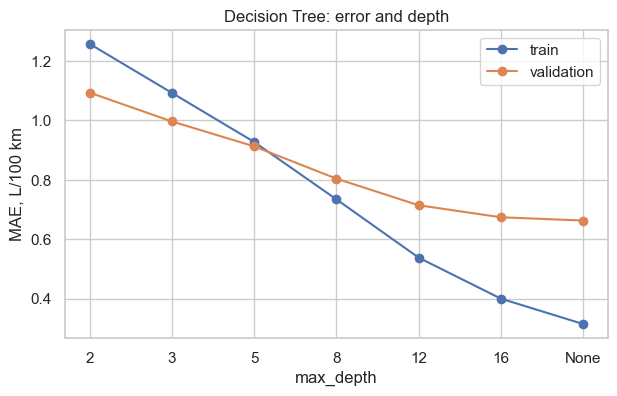

Best depth: None


,MAE,RMSE,R2
Mean baseline,2.123,2.663,-0.000
Linear Regression,0.802,1.074,0.837
Decision Tree,0.662,0.963,0.869
KNN,0.746,1.037,0.848


In [42]:
depths = [2, 3, 5, 8, 12, 16, None]
rows = []
for d in depths:
    m = Pipeline([("prep", preprocessor_base),
                  ("model", DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    m.fit(X_train, y_train)
    rows.append({
        "max_depth": str(d),
        "MAE_train": mean_absolute_error(y_train, m.predict(X_train)),
        "MAE_val": mean_absolute_error(y_val, m.predict(X_val)),
    })
tree_depth = pd.DataFrame(rows)
display(tree_depth.round(3))

plt.figure(figsize=(7, 4))
plt.plot(tree_depth["max_depth"], tree_depth["MAE_train"], marker="o", label="train")
plt.plot(tree_depth["max_depth"], tree_depth["MAE_val"], marker="o", label="validation")
plt.xlabel("max_depth"); plt.ylabel("MAE, L/100 km")
plt.title("Decision Tree: error and depth"); plt.legend(); plt.show()

best_depth = depths[tree_depth["MAE_val"].idxmin()]
print("Best depth:", best_depth)

tree = Pipeline([("prep", preprocessor_base),
                 ("model", DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE))])
tree.fit(X_train, y_train)
results["Decision Tree"] = evaluate(y_val, tree.predict(X_val))
pd.DataFrame(results).T.round(3)

**Result:** the best depth = `None` (MAE on validation = 0.662,
RMSE = 0.963, R² = 0.869). 

**Conclusion:** as the depth grows, the error on train
falls to 0.314, while on validation it slows down. Up to depth 5 the curves
almost coincide (0.927 and 0.912), and after depth 8 train goes down
faster. The gain of `None` over depth 16 is tiny (0.662 versus
0.673), i.e. the curve has reached a plateau. The gap between train (0.314) and
validation (0.662) remains large, so the tree is overfitted. But on
new `Make + Model` groups it is still better than Linear Regression,
so we keep `max_depth=None`, and in the plan for the final we will check
a restriction via `min_samples_leaf`.

## 7.4 KNN Regressor

**Idea:** for a new car we find the k most similar ones in train and take
the mean of their consumption. 

**Preprocessor:** `preprocessor_knn` (without
scaling). 

**Important:** KNN computes
distances in the original units, so features with a large range
(`Cylinders`, `gears`, `Model year`) have a stronger influence, and one-hot columns
a weaker one. 

**Choosing k:** a small k gives noisy predictions
(overfitting), a large one smooths too much.

,k,MAE_train,MAE_val
0,1,0.359,0.796
1,3,0.474,0.748
2,5,0.539,0.746
3,10,0.652,0.791
4,15,0.729,0.803
5,20,0.782,0.816
6,30,0.854,0.837
7,50,0.937,0.882


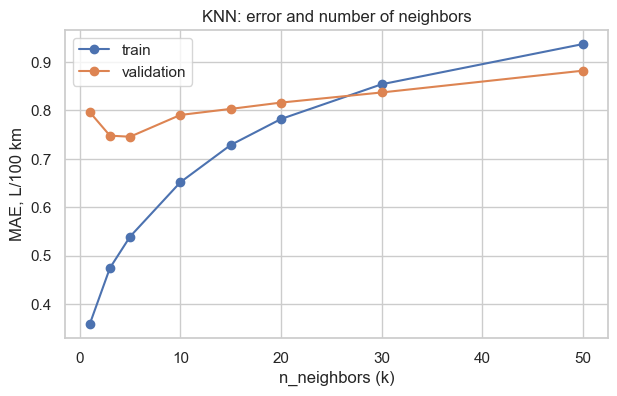

Best k: 5


,MAE,RMSE,R2
Mean baseline,2.123,2.663,-0.000
Linear Regression,0.802,1.074,0.837
Decision Tree,0.662,0.963,0.869
KNN,0.746,1.037,0.848


In [43]:
ks = [1, 3, 5, 10, 15, 20, 30, 50]
rows = []
for k in ks:
    m = Pipeline([("prep", preprocessor_knn),
                  ("model", KNeighborsRegressor(n_neighbors=k))])
    m.fit(X_train, y_train)
    rows.append({
        "k": k,
        "MAE_train": mean_absolute_error(y_train, m.predict(X_train)),
        "MAE_val": mean_absolute_error(y_val, m.predict(X_val)),
    })
knn_k = pd.DataFrame(rows)
display(knn_k.round(3))

plt.figure(figsize=(7, 4))
plt.plot(knn_k["k"], knn_k["MAE_train"], marker="o", label="train")
plt.plot(knn_k["k"], knn_k["MAE_val"], marker="o", label="validation")
plt.xlabel("n_neighbors (k)"); plt.ylabel("MAE, L/100 km")
plt.title("KNN: error and number of neighbors"); plt.legend(); plt.show()

best_k = int(knn_k.loc[knn_k["MAE_val"].idxmin(), "k"])
print("Best k:", best_k)

knn = Pipeline([("prep", preprocessor_knn),
                ("model", KNeighborsRegressor(n_neighbors=best_k))])
knn.fit(X_train, y_train)
results["KNN"] = evaluate(y_val, knn.predict(X_val))
pd.DataFrame(results).T.round(3)

**Result:** the best k = 5 (MAE on validation = 0.746, RMSE = 1.037,
R² = 0.848). 

**Conclusion:** at k=1 the error on train is 0.359 (not zero, because
cars identical in features have slightly different consumption), and on
validation 0.796. The minimum on validation is at k=3-5 (0.748 and 0.746),
after that the error grows (0.882 at k=50), i.e. the smoothing becomes
too strong. KNN is better than Linear Regression (0.802), but worse than Decision
Tree (0.662). Without scaling KNN is noticeably weaker: in a trial
run with `StandardScaler` the MAE was 0.667. This is the price of the project
requirement.

## 7.5 Cross-validation (GroupKFold, 5 folds)

**Why:** the result on a single validation set may be random. CV
checks the model on 5 different splits of train. 

**Why GroupKFold:**
the `Make + Model` groups do not overlap between folds, so there is no leakage
of "almost identical cars", just as in the main split. Test does not
take part in CV.

In [45]:
from sklearn.model_selection import GroupKFold

cv = GroupKFold(n_splits=5)

models = {
    "Linear Regression": Pipeline([("prep", preprocessor_base), ("model", LinearRegression())]),
    "Decision Tree": Pipeline([("prep", preprocessor_base),
                               ("model", DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE))]),
    "KNN": Pipeline([("prep", preprocessor_knn),
                     ("model", KNeighborsRegressor(n_neighbors=best_k))]),
}
scoring = {"mae": "neg_mean_absolute_error",
           "rmse": "neg_root_mean_squared_error",
           "r2": "r2"}

cv_rows = []
for name, model in models.items():
    s = cross_validate(model, X_train, y_train, cv=cv, groups=g_train, scoring=scoring)
    cv_rows.append({
        "model": name,
        "MAE_mean": -s["test_mae"].mean(), "MAE_std": s["test_mae"].std(),
        "RMSE_mean": -s["test_rmse"].mean(),
        "R2_mean": s["test_r2"].mean(), "R2_std": s["test_r2"].std(),
    })
cv_table = pd.DataFrame(cv_rows).set_index("model")
cv_table.round(3)

,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std
model,,,,,
Linear Regression,0.880,0.049,1.176,0.839,0.014
Decision Tree,0.736,0.040,1.099,0.859,0.007
KNN,0.816,0.019,1.111,0.856,0.014


**Result:** see the table (mean and std across folds).

| Model | MAE (mean ± std) | R² (mean) |
|---|---|---|
| Decision Tree | 0.736 ± 0.040 | 0.839 |
| KNN | 0.816 ± 0.019 | 0.856 |
| Linear Regression | 0.880 ± 0.049 | 0.856 |

**Conclusion:** the order of the models matches validation: Decision Tree is
better than KNN, and KNN is better than Linear Regression. Std is about 4% of the
mean MAE, and the gap between the models (0.09-0.17) is noticeably larger than the std,
so the order is stable. The CV error is higher than on validation (0.736
versus 0.662 for the tree): on the single validation set we were slightly lucky with the
composition of the groups, and CV gives a more honest estimate.

## 7.6 Checking the Model year feature

At stage 5 we kept `Model year` conditionally: its correlation with the target is about
zero (-0.01). For KNN without scaling this feature is especially suspicious,
because its range (2014-2025) distorts the distances. **Check:**
we compare MAE on validation with and without this feature for all three
models.

In [46]:
def build_preps(num_list):
    base = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_list),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    knn_p = base
    return base, knn_p

def make_models(num_list, depth, k):
    base, knn_p = build_preps(num_list)
    return {
        "Linear Regression": Pipeline([("prep", base), ("model", LinearRegression())]),
        "Decision Tree": Pipeline([("prep", base), ("model", DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE))]),
        "KNN": Pipeline([("prep", knn_p), ("model", KNeighborsRegressor(n_neighbors=k))]),
    }

num_with_year = list(num_cols)
num_no_year = [c for c in num_cols if c != "Model year"]

rows = []
for label, nl in [("with Model year", num_with_year), ("without Model year", num_no_year)]:
    for name, m in make_models(nl, best_depth, best_k).items():
        m.fit(X_train, y_train)
        rows.append({"model": name, "variant": label,
                     "MAE_val": mean_absolute_error(y_val, m.predict(X_val))})
year_check = pd.DataFrame(rows).pivot(index="model", columns="variant", values="MAE_val")
year_check.round(3)

variant,with Model year,without Model year
model,,
Decision Tree,0.662,0.674
KNN,0.746,0.715
Linear Regression,0.802,0.801


**Result:** Decision Tree: 0.662 with the year and 0.674 without. Linear
Regression: 0.802 and 0.801 (no difference). KNN: 0.746 with the year and 0.715
without.

**Decision:** we keep `Model year` (`USE_YEAR = True`). For the best
model (Decision Tree) the feature gives a small gain (0.012), and for the
linear model it changes nothing. For KNN without scaling the year hurts
(0.031), because its range 2014-2025 distorts the distances. But
the difference for the tree is smaller than the std in CV (0.026), so the gain is modest.
A single feature set for all models is simpler and fairer when
comparing. We note the KNN-without-year variant in the plan for the final.

## 7.7 Final evaluation on test

**Order:** the hyperparameters and the feature set have already been chosen on
validation and CV. Now we train each model on train + validation
(more data) and compute the metrics on test **once**. We do not change decisions
after that.

In [49]:
USE_YEAR = True
final_num = num_with_year if USE_YEAR else num_no_year

X_trval = pd.concat([X_train, X_val])
y_trval = pd.concat([y_train, y_val])

final_models = make_models(final_num, best_depth, best_k)
test_results = {}

d_final = DummyRegressor(strategy="mean").fit(X_trval, y_trval)
test_results["Mean baseline"] = evaluate(y_test, d_final.predict(X_test))

test_preds = {}
for name, m in final_models.items():
    m.fit(X_trval, y_trval)
    test_preds[name] = m.predict(X_test)
    test_results[name] = evaluate(y_test, test_preds[name])

test_table = pd.DataFrame(test_results).T
display(test_table.round(3))

best_name = test_table.drop("Mean baseline")["MAE"].idxmin()
ratio = test_table.loc["Mean baseline", "MAE"] / test_table.loc[best_name, "MAE"]
print(f"Best model: {best_name}")
print(f"MAE baseline / best MAE = {ratio:.2f}  (need ≥ 2)")
print(f"Best R² = {test_table.loc[best_name, 'R2']:.3f}  (need ≥ 0.8)")

,MAE,RMSE,R2
Mean baseline,2.211,2.835,-0.000
Linear Regression,0.780,1.028,0.868
Decision Tree,0.628,0.920,0.895
KNN,0.715,0.973,0.882


Best model: Decision Tree
MAE baseline / best MAE = 3.52  (need ≥ 2)
Best R² = 0.895  (need ≥ 0.8)


**Result:**

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Mean baseline | 2.211 | 2.835 | -0.000 |
| Linear Regression | 0.780 | 1.028 | 0.868 |
| Decision Tree | 0.628 | 0.920 | 0.895 |
| KNN | 0.715 | 0.973 | 0.882 |

**Success criterion:** the MAE of the best model is at least half that of the baseline,
R² ≥ 0.8 → **met**. The MAE of Decision Tree is 0.628 versus 2.211 for the
baseline (3.52 times lower, ≥ 2 needed), R² = 0.895 (≥ 0.8 needed).

**Conclusion:** the best model is Decision Tree, followed by KNN and Linear Regression.
The order is the same as on validation and in CV, so the choice of model
is not random. The MAE on test (0.628) is lower than in CV (0.736): part of the gain
comes from retraining on train + validation, and part, probably, from the composition of the
test groups. Therefore it is worth relying on both numbers.

## 7.8 Error analysis

We look at where the best model (Decision Tree) makes the largest errors, by
slices: vehicle class, fuel type, number of cylinders, hybrids. On the
plots the points lie along the diagonal, and the errors are distributed symmetrically
around zero and mostly fit within ±1 L/100 km. The heavy tails
reach ±4 L/100 km.

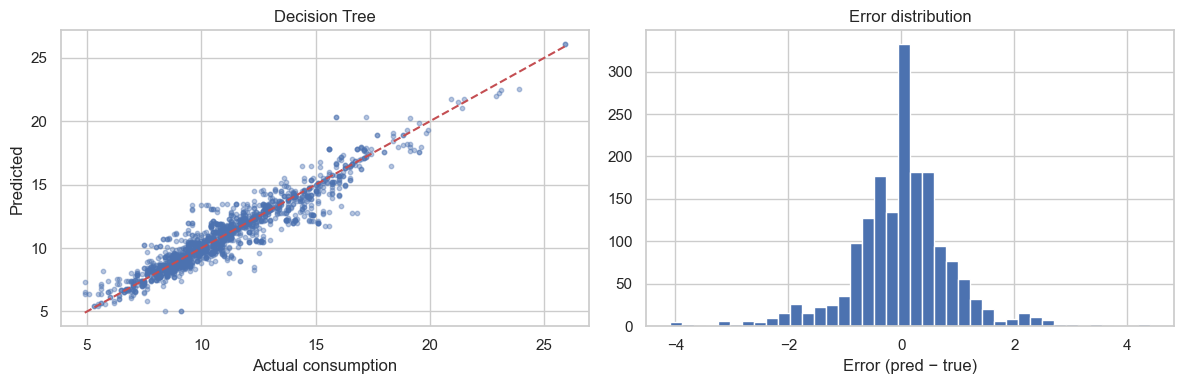


=== MAE by: Vehicle class


,n,MAE,bias
Vehicle class,,,
Pickup truck: Small,84,0.97,0.46
Subcompact,123,0.90,-0.59
Pickup truck: Standard,91,0.78,0.14
Sport utility vehicle: Standard,233,0.77,0.25
Station wagon: Mid-size,13,0.66,-0.14
Van: Passenger,10,0.63,-0.49
Sport utility vehicle: Small,334,0.61,0.03
Special purpose vehicle,14,0.60,-0.06
Mid-size,226,0.58,0.03



=== MAE by: Fuel type


,n,MAE,bias
Fuel type,,,
E,69,0.90,-0.00
Z,832,0.66,-0.11
X,793,0.58,0.10
D,57,0.51,-0.00



=== MAE by: Cylinders


,n,MAE,bias
Cylinders,,,
16,1,0.80,-0.80
8,320,0.72,-0.26
6,528,0.64,0.07
4,812,0.59,0.04
12,55,0.59,0.07
10,18,0.46,-0.20
3,16,0.43,0.10
5,1,0.20,-0.20



=== MAE by: is_hybrid


,n,MAE,bias
is_hybrid,,,
True,45,1.03,0.96
False,1706,0.62,-0.03


,Make,Model,Vehicle class,Fuel type,Engine size (L),y_true,y_pred,abs_error
4422,Bentley,bentayga,Sport utility vehicle: Standard,Z,6.0,15.9,20.30,4.40
3356,Bentley,bentayga,Sport utility vehicle: Standard,Z,6.0,15.9,20.30,4.40
7903,Honda,accord sport/touring,Full-size,X,2.0,9.1,5.00,4.10
8878,Honda,accord sport/touring,Full-size,X,2.0,9.1,5.00,4.10
1292,Chevrolet,camaro zl1,Compact,Z,6.2,16.8,12.80,4.00
1926,Mitsubishi,lancer evolution,Compact,Z,2.0,12.3,8.30,4.00
3480,Chevrolet,camaro zl1,Subcompact,Z,6.2,15.6,11.70,3.90
193,Chevrolet,camaro zl1,Compact,Z,6.2,16.6,12.80,3.80
823,Mitsubishi,lancer evolution,Compact,Z,2.0,12.3,8.50,3.80
8755,Ford,explorer hybrid awd,Sport utility vehicle: Standard,X,3.3,9.6,13.38,3.78


In [50]:
y_pred = test_preds[best_name]
err = X_test.copy()
err["y_true"] = y_test.values
err["y_pred"] = y_pred
err["error"] = err["y_pred"] - err["y_true"]
err["abs_error"] = err["error"].abs()
err[["Make", "Model"]] = df.loc[X_test.index, ["Make", "Model"]]
err["is_hybrid"] = err["Model"].str.contains("hybrid", case=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(err["y_true"], err["y_pred"], s=10, alpha=0.4)
lims = [err["y_true"].min(), err["y_true"].max()]
ax[0].plot(lims, lims, "r--")
ax[0].set_xlabel("Actual consumption"); ax[0].set_ylabel("Predicted"); ax[0].set_title(best_name)
ax[1].hist(err["error"], bins=40)
ax[1].set_xlabel("Error (pred − true)"); ax[1].set_title("Error distribution")
plt.tight_layout(); plt.show()

def by(col):
    return (err.groupby(col)
            .agg(n=("abs_error", "size"), MAE=("abs_error", "mean"), bias=("error", "mean"))
            .round(2).sort_values("MAE", ascending=False))

for col in ["Vehicle class", "Fuel type", "Cylinders", "is_hybrid"]:
    print(f"\n=== MAE by: {col}")
    display(by(col))

cols = ["Make", "Model", "Vehicle class", "Fuel type", "Engine size (L)", "y_true", "y_pred", "abs_error"]
err.sort_values("abs_error", ascending=False)[cols].head(10).round(2)

**Findings:**

1. **Hybrids (the strongest effect).** The MAE for hybrids is 1.03 with a
   bias of +0.96, versus 0.60 and -0.04 for the rest. The test set has only 45 hybrids
   out of 1751 (2.6%). The model overestimates their consumption by about 1 L/100 km,
   because there is no "hybrid" feature in the set: it sees only engine size and
   class, and the engine of a regular and a hybrid car can be the same.
2. **Powerful and "supercharged" versions.** In the top 10 errors, six rows
   are taken by the Chevrolet Camaro ZL1 (6.2 L, true consumption 15.4-16.8,
   prediction 11.7-12.8) and the Mitsubishi Lancer Evolution (2.0 L, true
   12.3, prediction 8.3-8.5). The model treats them as ordinary cars with the same
   engine size and underestimates consumption by 3.7-4.0. This, in particular, affects
   the high MAE for the Subcompact class (0.90, bias -0.59). For 8
   cylinders the bias is -0.27 and the MAE 0.71, i.e. heavy engines are
   underestimated on average.
3. **Fuel type and class.** E85 has the largest error among fuels
   (MAE 0.90, n=69), while diesel and regular gasoline are lower (0.51 and 0.56).
   Among classes the worst is Pickup truck: Small (0.98, n=84, bias
   +0.47) and Subcompact. The smallest errors are for Full-size (0.40) and
   Van: Cargo (0.35), but the latter has only 5 rows, so
   this result cannot be considered reliable.
4. **Rare groups.** For 5 and 16 cylinders there is 1 row each in test,
   so no conclusions can be drawn. But 10 cylinders (n=18) have small errors
   (MAE 0.46): the rarity of a group does not by itself guarantee a large
   error.
5. **A caveat about the top 10.** The rows for Camaro, Accord, Lancer, and Explorer
   repeat because of different model years. All of them are in test, because the
   group split keeps one `Make + Model` pair in one part. Therefore there are fewer independent
   "bad cars" than rows.

**What can be improved for the final:** add an `is_hybrid` feature based on the
model name (caveat: not all hybrids have the word
hybrid in the name); think about a feature for "supercharged" versions; check
a tree depth restriction via `min_samples_leaf`.

## 7.9 Stage 7 summary

**Model comparison (test):**

- The best model: **Decision Tree** (MAE = 0.628, R² = 0.895), which is
  **3.52 times** better than the baseline (MAE 2.211).
- Success criterion: **met** (MAE at least half that of the baseline,
  R² ≥ 0.8).
- Cross-validation: MAE = 0.736 ± 0.040, the result is **stable**.
  The order of the models (Decision Tree, KNN, Linear Regression) matches
  validation and test.
- For Linear Regression and Decision Tree this does not affect the result, but KNN lost
  because of it (MAE 0.715 on test, 0.746 on validation).

**Limitations:**

- The data has no vehicle weight or power; instead we use
  engine size, cylinders, and class. Therefore the model underestimates "supercharged" versions
  (Camaro ZL1, Lancer Evolution) by 3.7-4.0 L/100 km.
- There is no "hybrid" feature, and consumption for hybrids is overestimated on average by
  0.96 L/100 km (45 cars in test).
- Rare groups (5 and 16 cylinders, Van: Cargo, E85) are evaluated on a
  small number of examples, so no reliable conclusions can be drawn about them.
- Decision Tree with `max_depth=None` is overfitted (MAE train 0.314 versus
  0.662 on validation), although it is the best of the three.
- The split is random over groups, so the composition of test depends on
  `RANDOM_STATE`. The MAE on test (0.628) is lower than CV (0.736), and this should be
  taken into account when evaluating.

### **Open problems:**

- Decision Tree with `max_depth=None` is overfitted, and a depth restriction has not been tested yet.
- There is no "hybrid" feature, so consumption for hybrids is overestimated.
- "Supercharged" versions (Camaro ZL1, Lancer Evolution) are underestimated because the data has no power.
- E85 and the rare groups (5 and 16 cylinders, Van: Cargo) are evaluated on too few examples.
- KNN without scaling is hurt by `Model year` (0.746 with the year versus 0.715 without on validation).
- Generalization over time has not been checked: the split is random over groups, not by year.

### **Plan for the final:**

- Tuning the tree hyperparameters via GridSearchCV with GroupKFold
  (`max_depth`, `min_samples_leaf`).
- An `is_hybrid` feature based on the model name and re-evaluation of hybrids.
- A check over time: train on 2014-2023, test on 2024-2025.
- A separate discussion of E85 and "supercharged" versions; KNN without
  `Model year` (0.715 instead of 0.746 on validation).